<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/add%2Fmodel4-6/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Activation, LeakyReLU
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [ ]:
# generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [ ]:
aug_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/augmented_images/augmented_images1",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

Found 13640 files belonging to 62 classes.


In [ ]:
#normalize
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [ ]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
aug_ds = aug_ds.map(process)

images, label = next(iter(aug_ds))
images.shape, label.shape

(TensorShape([64, 128, 128, 3]), TensorShape([64]))

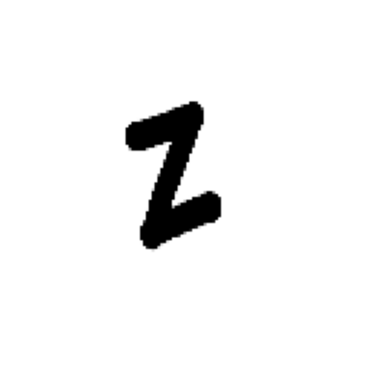

In [ ]:

#print Z
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [ ]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

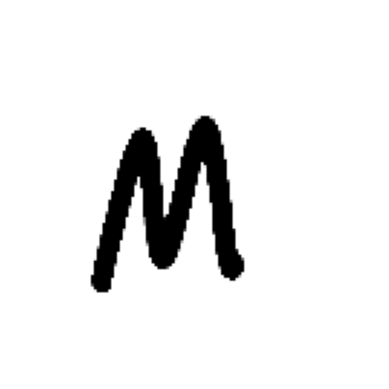

In [ ]:
#print M
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [ ]:
def accuracy_vs_epochs(history):
  hist_dict = history.history if hasattr(history, 'history') else history
  plt.plot(hist_dict['accuracy'], label='accuracy')
  plt.plot(hist_dict['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.ylim(0, 1)
  plt.legend(loc='lower right')
  plt.show()

In [ ]:
import pickle


BASE_PATH = '/content/drive/MyDrive/handwritten_english_character_and_digits'

def make_callbacks(model_name):
    """Creates a fresh checkpoint + early_stop pair for a given model name."""
    model_dir = f'{BASE_PATH}/{model_name}'
    os.makedirs(model_dir, exist_ok=True)  # creates folder if missing, no error if it exists

    checkpoint_cb = keras.callbacks.ModelCheckpoint(
        f'{model_dir}/{model_name}_checkpoint.keras',
        save_best_only=True,
        monitor='val_loss'
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    return [early_stop, checkpoint_cb]

def save_history(history_obj, model_name, stage):
    """Saves a Keras History object's .history dict to Drive.
    stage e.g. 'original' or 'augmented' """
    model_dir = f'{BASE_PATH}/{model_name}'
    os.makedirs(model_dir, exist_ok=True)

    with open(f'{model_dir}/{model_name}_history_{stage}.pkl', 'wb') as f:
        pickle.dump(history_obj.history, f)
    print(f"Saved: {model_name}_history_{stage}.pkl")

In [ ]:
def restore_model(model_name):
    """Loads a saved model checkpoint if it exists, else returns None."""
    path = f'{BASE_PATH}/{model_name}/{model_name}_checkpoint.keras'
    if os.path.exists(path):
        model = keras.models.load_model(path)
        print(f"✅ Restored {model_name} from checkpoint")
        return model
    else:
        print(f"⚠️  No checkpoint found for {model_name} — needs training from scratch")
        return None

def restore_history(model_name, stage):
    """Loads a saved history dict if it exists, else returns None."""
    path = f'{BASE_PATH}/{model_name}/{model_name}_history_{stage}.pkl'
    if os.path.exists(path):
        with open(path, 'rb') as f:
            history = pickle.load(f)
        print(f"✅ Restored {model_name} {stage} history ({len(history['loss'])} epochs)")
        return history
    else:
        print(f"⚠️  No {stage} history found for {model_name}")
        return None

In [ ]:
# fiting function for simplicity
def training(model, model_name, training_data, val_ds, stage):
    history = model.fit(
        training_data, epochs=100, validation_data=val_ds,
        callbacks=make_callbacks(model_name)
    )
    save_history(history, model_name, stage)
    return history

In [ ]:
#model 1
model1 = Sequential([
    Conv2D(32, (3,3), activation= 'relu', padding = "same", input_shape = (128, 128, 3)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(160, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(62, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,574 (6.09 MB)

 Trainable params: 1,596,574 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = training(model1, 'model1', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 603s 7s/step - accuracy: 0.0825 - loss: 3.8262 - val_accuracy: 0.2903 - val_loss: 2.7464
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.4359 - loss: 2.1254 - val_accuracy: 0.5381 - val_loss: 1.7608
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 251ms/step - accuracy: 0.6675 - loss: 1.1571 - val_accuracy: 0.6554 - val_loss: 1.3075
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.7966 - loss: 0.6758 - val_accuracy: 0.6848 - val_loss: 1.3581
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 258ms/step - accuracy: 0.8732 - loss: 0.4027 - val_accuracy: 0.6921 - val_loss: 1.5339
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 257ms/step - accuracy: 0.9201 - loss: 0.2590 - val_accuracy: 0.6804 - val_loss: 1.6957
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 249ms/step - accuracy: 0.9465 - loss: 0.1817 - val_accuracy: 0.6935 - val_loss: 1.6186
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.9615 - loss: 0.1162 - va

In [ ]:
history1_2 = training(model1, 'model1', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2534s 12s/step - accuracy: 0.4906 - loss: 1.8850 - val_accuracy: 0.7405 - val_loss: 0.8145
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 105s 489ms/step - accuracy: 0.7625 - loss: 0.7584 - val_accuracy: 0.7771 - val_loss: 0.7230
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 464ms/step - accuracy: 0.8634 - loss: 0.4126 - val_accuracy: 0.8006 - val_loss: 0.6812
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 143s 470ms/step - accuracy: 0.9103 - loss: 0.2593 - val_accuracy: 0.8123 - val_loss: 0.7190
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 139s 453ms/step - accuracy: 0.9378 - loss: 0.1762 - val_accuracy: 0.8314 - val_loss: 0.7050
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 100s 466ms/step - accuracy: 0.9553 - loss: 0.1293 - val_accuracy: 0.8021 - val_loss: 0.8286
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 98s 457ms/step - accuracy: 0.9630 - loss: 0.1081 - val_accuracy: 0.8123 - val_loss: 0.8730
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 101s 473ms/step - accuracy: 0.9

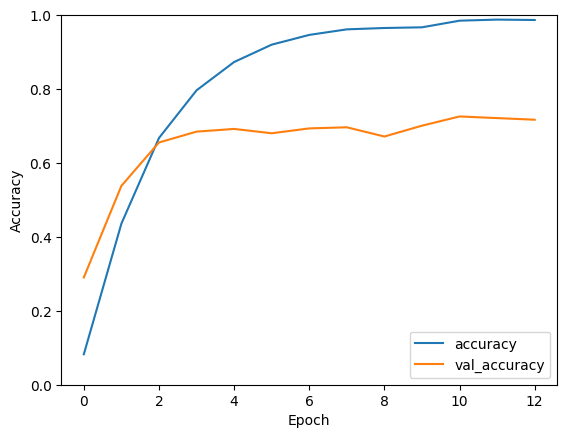

In [ ]:
accuracy_vs_epochs(history1)

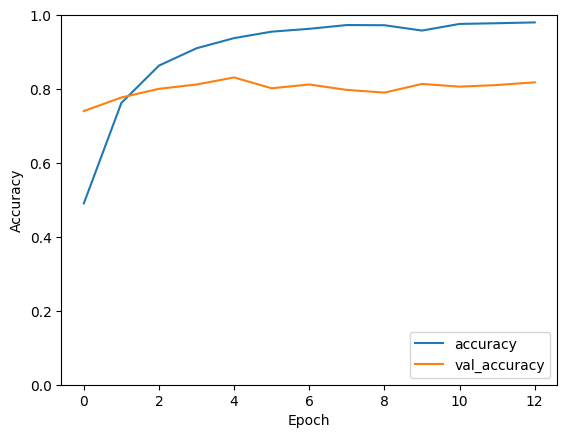

In [ ]:
accuracy_vs_epochs(history1_2)

In [ ]:
#model 2
model2 = Sequential([
    Conv2D(32, (3,3), activation= 'relu',  input_shape = (128, 128, 3)),

    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(64, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(128, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(160, (3,3), activation= 'relu'),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Flatten(),
    Dense(64, activation='relu'),

    Dense(62, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,462 (2.48 MB)

 Trainable params: 650,462 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = training(model2, 'model2', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.0301 - loss: 4.0745 - val_accuracy: 0.0762 - val_loss: 3.7410
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 264ms/step - accuracy: 0.2317 - loss: 3.0548 - val_accuracy: 0.4003 - val_loss: 2.2401
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.5301 - loss: 1.6942 - val_accuracy: 0.5601 - val_loss: 1.6061
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 276ms/step - accuracy: 0.7100 - loss: 1.0137 - val_accuracy: 0.6584 - val_loss: 1.2402
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 267ms/step - accuracy: 0.7944 - loss: 0.6633 - val_accuracy: 0.6730 - val_loss: 1.2282
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step - accuracy: 0.8622 - loss: 0.4343 - val_accuracy: 0.6701 - val_loss: 1.4819
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 244ms/step - accuracy: 0.8977 - loss: 0.3236 - val_accuracy: 0.6789 - val_loss: 1.4842
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 261ms/step - accuracy: 0.9249 - loss: 0.2324 - 

In [ ]:
history21= training(model2, 'model2', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 96s 447ms/step - accuracy: 0.4876 - loss: 1.9029 - val_accuracy: 0.7595 - val_loss: 0.7421
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 94s 441ms/step - accuracy: 0.7163 - loss: 0.8964 - val_accuracy: 0.8050 - val_loss: 0.6099
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 143s 448ms/step - accuracy: 0.8223 - loss: 0.5456 - val_accuracy: 0.7977 - val_loss: 0.6128
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 96s 447ms/step - accuracy: 0.8741 - loss: 0.3677 - val_accuracy: 0.8167 - val_loss: 0.6690
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 97s 450ms/step - accuracy: 0.9097 - loss: 0.2546 - val_accuracy: 0.8079 - val_loss: 0.7313
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 96s 450ms/step - accuracy: 0.9399 - loss: 0.1789 - val_accuracy: 0.8240 - val_loss: 0.7624
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 95s 442ms/step - accuracy: 0.9464 - loss: 0.1477 - val_accuracy: 0.8109 - val_loss: 0.7845
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 94s 438ms/step - accuracy: 0.9518 

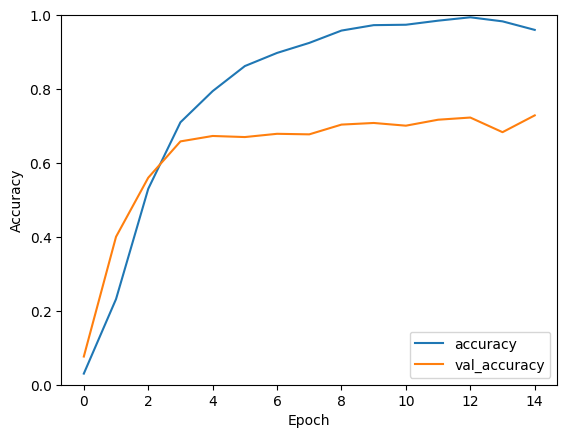

In [ ]:
accuracy_vs_epochs(history2)

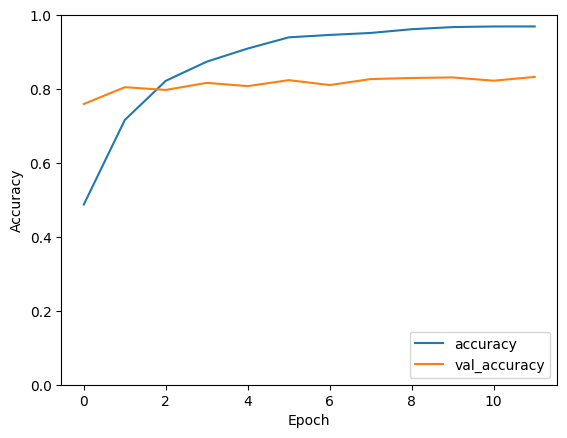

In [ ]:
accuracy_vs_epochs(history21)

## Overfitting and Data Augmentation

Our initial models suffered from **overfitting**, partly due to the relatively small original training set of around 2,000 images. With limited data, a CNN can memorize training examples rather than learning features that generalize to unseen samples.

To address this, we continued training each model on an **augmented dataset** of ~13,000 images, generated via small rotations, shifts, and zooms. This exposes the model to more variation and encourages it to learn features that don't depend on the exact pose or position of the original samples.

This round of training also introduced **checkpointing** (`ModelCheckpoint`, saving best weights by `val_loss`) and **early stopping** (`patience=10`, `restore_best_weights=True`). Because weights are restored based on lowest `val_loss` rather than highest `val_accuracy`, the reported figures below reflect the model's performance *at that restored checkpoint*, not the peak accuracy observed at any point during training.

### Model 1

On the original dataset, Model 1's lowest val_loss (1.3075) occurred at epoch 3, corresponding to a validation accuracy of **65.54%**. Continuing on the augmented dataset, the lowest val_loss (0.6812) occurred at epoch 3, corresponding to **80.06%** validation accuracy.

Training accuracy continued climbing well past this point (to 97.81% by epoch 13), while val_loss also climbed after epoch 3 — from 0.68 up to 1.12 — even as val_accuracy briefly touched higher values (83.14% at epoch 5) before declining again. This is a clear overfitting signature: the model's most *confident and reliable* checkpoint is not its highest-accuracy epoch.

### Model 2

On the original dataset, Model 2's lowest val_loss (1.2282) occurred at epoch 5, corresponding to **67.30%** validation accuracy. On the augmented dataset, the lowest val_loss (0.6099) occurred very early — epoch 2 — corresponding to **80.50%** validation accuracy.

As with Model 1, later epochs reached higher raw accuracy (up to 83.28% at epoch 12) but at steadily increasing val_loss, meaning those later checkpoints are less trustworthy despite the higher accuracy number.

### Comparison (restored checkpoint — lowest val_loss)

| Model | Original Data (val acc @ best val_loss) | Augmented Data (val acc @ best val_loss) | Best val_loss (augmented) |
|-------|---------------:|---------------:|---------------:|
| Model 1 | 65.54% (epoch 3) | 80.06% (epoch 3) | 0.6812 |
| Model 2 | 67.30% (epoch 5) | 80.50% (epoch 2) | **0.6099** |

Model 2 remains marginally ahead of Model 1 at their respective best-val_loss checkpoints, both in accuracy and in loss. Notably, both models' lowest-loss checkpoints occur early in the augmented-data run (epoch 2–3), well before training accuracy plateaus — reinforcing that **letting training run longer does not mean the model keeps improving on unseen data**, and that `val_loss` is a more trustworthy stopping signal than `val_accuracy` alone.

This motivates the next phase of experiments: Model 3 introduces BatchNormalization + Dropout + a reduced learning rate, and Models 4–6 explore LeakyReLU (with and without BatchNormalization) to address a dying-ReLU collapse observed during Model 3's initial training, and to isolate which architectural change actually improves generalization rather than just raw peak accuracy.

In [ ]:
def restore_full(model_name):
    model = restore_model(model_name)
    histories = {
        'original': restore_history(model_name, 'original'),
        'augmented': restore_history(model_name, 'augmented')
    }
    return model, histories

#examples
'''
model1, histories = restore_full('model1')
histories['model3']['augmented']['val_accuracy']
model1.evaluate(validation_ds)
'''


"\nmodel1, histories = restore_full('model1')\nhistories['model3']['augmented']['val_accuracy']\nmodel1.evaluate(validation_ds)\n"

In [ ]:
def restore_all(n):
    models = {}
    histories = {}
    for i in range(1, n+1):
        name = f'model{i}'
        models[name] = restore_model(name)
        histories[name] = {
            'original': restore_history(name, 'original'),
            'augmented': restore_history(name, 'augmented')
        }
    return models, histories
#examples
''' models, histories = restore_all(6)
histories['model3']['augmented']['val_accuracy']
models['model1'].evaluate(validation_ds) '''

" models, histories = restore_all(6)\nhistories['model3']['augmented']['val_accuracy']\nmodels['model1'].evaluate(validation_ds) "

✅ Restored model1 from checkpoint
✅ Restored model1 original history (13 epochs)
✅ Restored model1 augmented history (13 epochs)


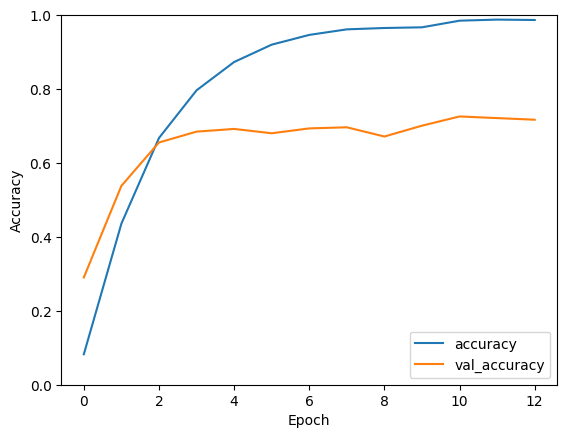

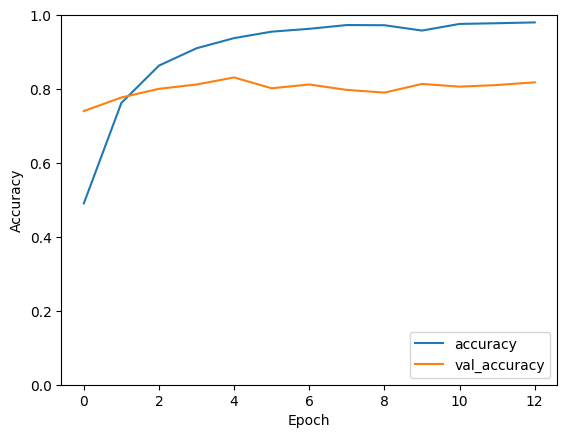

In [ ]:
model1 = restore_model('model1')
history1 = restore_history('model1', 'original')
history1_2 = restore_history('model1', 'augmented')
accuracy_vs_epochs(history1)
accuracy_vs_epochs(history1_2)

In [ ]:
#testing my model is actually correctly saved and restore or not
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,789,724 (18.27 MB)

 Trainable params: 1,596,574 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,193,150 (12.18 MB)

✅ Restored model2 from checkpoint
✅ Restored model2 original history (15 epochs)
✅ Restored model2 augmented history (12 epochs)


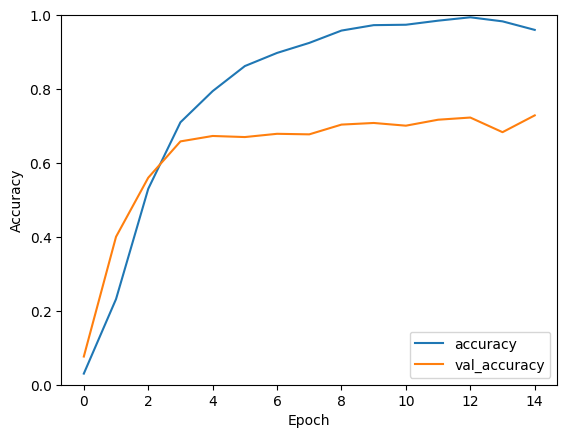

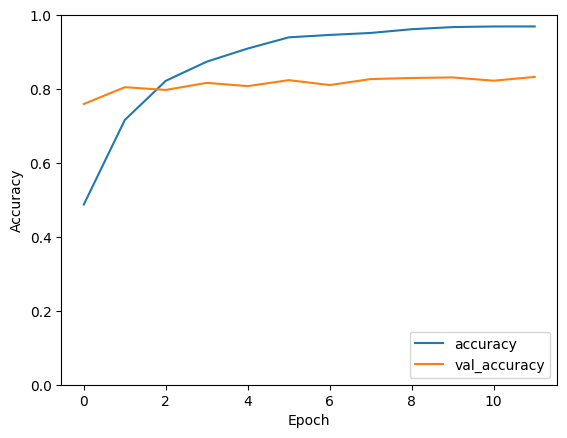

In [ ]:
model2, histories = restore_full('model2')
history2 = histories['original']
history21 = histories['augmented']
accuracy_vs_epochs(history2)
accuracy_vs_epochs(history21)

In [ ]:
# model 3 model2 + batchnormalization + dropout + custom learning rate
model3 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model3.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 12, 12, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,998 (2.49 MB)

 Trainable params: 651,230 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
history3 = training(model3, 'model3', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 323ms/step - accuracy: 0.0323 - loss: 4.0989 - val_accuracy: 0.0161 - val_loss: 4.1339
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 298ms/step - accuracy: 0.0773 - loss: 3.8284 - val_accuracy: 0.0323 - val_loss: 4.1542
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - accuracy: 0.1268 - loss: 3.5700 - val_accuracy: 0.0411 - val_loss: 4.1119
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.1657 - loss: 3.3415 - val_accuracy: 0.0616 - val_loss: 3.9631
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 285ms/step - accuracy: 0.2375 - loss: 3.0648 - val_accuracy: 0.1364 - val_loss: 3.6300
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 286ms/step - accuracy: 0.2698 - loss: 2.8670 - val_accuracy: 0.2566 - val_loss: 3.2886
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 274ms/step - accuracy: 0.3226 - loss: 2.6564 - val_accuracy: 0.3460 - val_loss: 2.8772
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 268ms/step - accuracy: 0.3680 - loss: 2.4480 - 

In [ ]:
model3 = restore_model("model3")
history3 = restore_history('model3', 'original')


✅ Restored model3 from checkpoint
✅ Restored model3 original history (48 epochs)


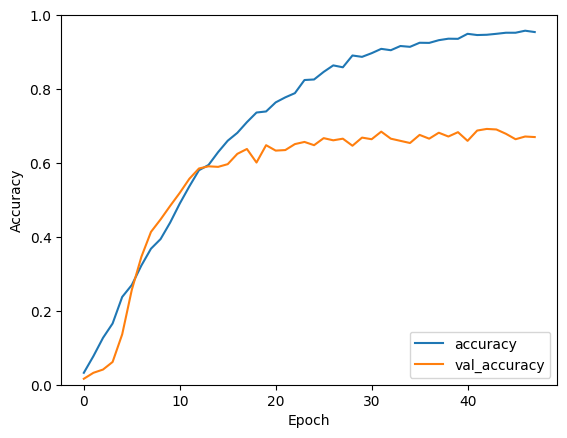

In [ ]:
accuracy_vs_epochs(history3)

In [ ]:
history3_1 = training(model3, 'model3', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2510s 12s/step - accuracy: 0.4190 - loss: 2.0497 - val_accuracy: 0.7214 - val_loss: 1.0070
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 100s 466ms/step - accuracy: 0.4542 - loss: 1.8960 - val_accuracy: 0.7390 - val_loss: 0.9509
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 98s 458ms/step - accuracy: 0.4909 - loss: 1.7573 - val_accuracy: 0.7155 - val_loss: 0.9917
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 465ms/step - accuracy: 0.5252 - loss: 1.6174 - val_accuracy: 0.7243 - val_loss: 0.9458
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 463ms/step - accuracy: 0.5511 - loss: 1.5189 - val_accuracy: 0.7698 - val_loss: 0.8048
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 461ms/step - accuracy: 0.5784 - loss: 1.4186 - val_accuracy: 0.7698 - val_loss: 0.7925
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 97s 451ms/step - accuracy: 0.5921 - loss: 1.3444 - val_accuracy: 0.7669 - val_loss: 0.8018
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 97s 454ms/step - accuracy: 0.6188 

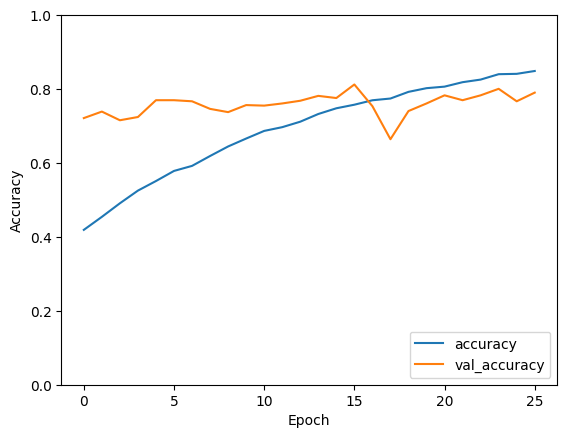

In [ ]:
accuracy_vs_epochs(history3_1)

In [ ]:
# model 4 model2 + batchnormalization + dropout + custom learning rate + LeakyReLU as activation
model4 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model4.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model4.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 12, 12, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,998 (2.49 MB)

 Trainable params: 651,230 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
history4 = training(model4, 'model4', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 695s 8s/step - accuracy: 0.0297 - loss: 4.1201 - val_accuracy: 0.0220 - val_loss: 4.1341
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 289ms/step - accuracy: 0.0587 - loss: 3.8960 - val_accuracy: 0.0161 - val_loss: 4.1696
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 278ms/step - accuracy: 0.1122 - loss: 3.6698 - val_accuracy: 0.0161 - val_loss: 4.1912
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - accuracy: 0.1514 - loss: 3.4619 - val_accuracy: 0.0161 - val_loss: 4.0579
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 287ms/step - accuracy: 0.1987 - loss: 3.2022 - val_accuracy: 0.0660 - val_loss: 3.7945
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 276ms/step - accuracy: 0.2460 - loss: 2.9988 - val_accuracy: 0.2141 - val_loss: 3.4179
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 278ms/step - accuracy: 0.3087 - loss: 2.7374 - val_accuracy: 0.3138 - val_loss: 3.0771
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 291ms/step - accuracy: 0.3416 - loss: 2.5481 - va

✅ Restored model4 from checkpoint
✅ Restored model4 original history (58 epochs)


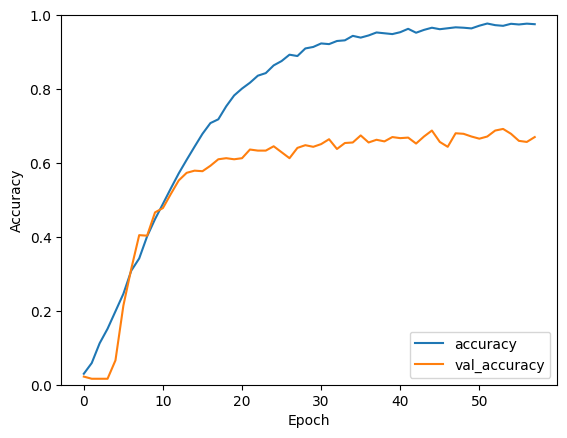

In [ ]:
model4 = restore_model("model4")
history4 = restore_history('model4', 'original')
accuracy_vs_epochs(history4)

In [ ]:
history4_1 = training(model4, 'model4', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4607s 21s/step - accuracy: 0.2010 - loss: 3.3356 - val_accuracy: 0.5748 - val_loss: 1.5557
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 100s 466ms/step - accuracy: 0.2806 - loss: 2.7665 - val_accuracy: 0.6393 - val_loss: 1.3202
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 98s 457ms/step - accuracy: 0.3389 - loss: 2.4510 - val_accuracy: 0.6965 - val_loss: 1.1492
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 103s 481ms/step - accuracy: 0.3913 - loss: 2.2322 - val_accuracy: 0.6554 - val_loss: 1.2392
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 139s 469ms/step - accuracy: 0.4271 - loss: 2.0367 - val_accuracy: 0.7067 - val_loss: 1.0156
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 464ms/step - accuracy: 0.4621 - loss: 1.8641 - val_accuracy: 0.7390 - val_loss: 0.9714
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 98s 460ms/step - accuracy: 0.5019 - loss: 1.7238 - val_accuracy: 0.7507 - val_loss: 0.8720
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 462ms/step - accuracy: 0.528

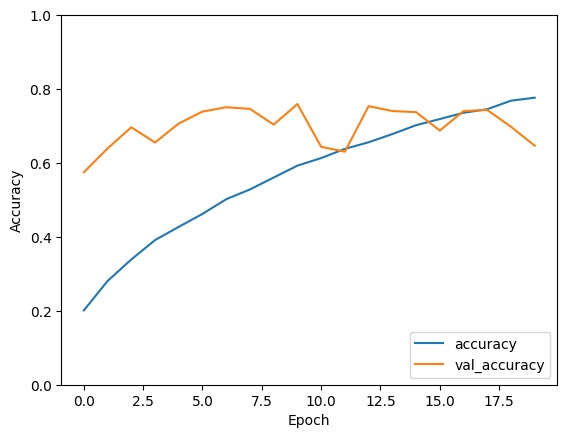

In [ ]:
accuracy_vs_epochs(history4_1)

In [ ]:
# model 5 model2 +  dropout + custom learning rate + LeakyReLU as activation
model5 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model5.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model5.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 12, 12, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,462 (2.48 MB)

 Trainable params: 650,462 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history5 = training(model5, 'model5', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1236s 14s/step - accuracy: 0.0158 - loss: 4.1271 - val_accuracy: 0.0381 - val_loss: 4.1192
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.0378 - loss: 4.0995 - val_accuracy: 0.0572 - val_loss: 4.0379
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - accuracy: 0.0634 - loss: 3.9455 - val_accuracy: 0.1041 - val_loss: 3.7529
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.1081 - loss: 3.7025 - val_accuracy: 0.1716 - val_loss: 3.4826
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - accuracy: 0.1441 - loss: 3.5056 - val_accuracy: 0.2111 - val_loss: 3.3016
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 245ms/step - accuracy: 0.1694 - loss: 3.3322 - val_accuracy: 0.2507 - val_loss: 3.0853
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 27s 317ms/step - accuracy: 0.2199 - loss: 3.0923 - val_accuracy: 0.3006 - val_loss: 2.8550
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.2603 - loss: 2.8840 - 

✅ Restored model5 from checkpoint
✅ Restored model5 original history (42 epochs)


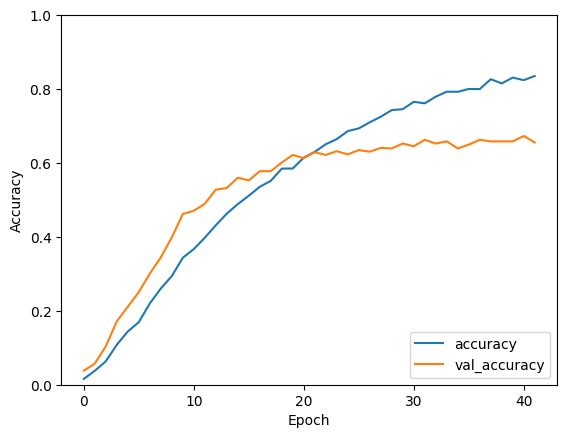

In [ ]:
model5 = restore_model("model5")
history5 = restore_history('model5', 'original')
accuracy_vs_epochs(history5)

In [ ]:
history5_1 = training(model5, 'model5', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4532s 21s/step - accuracy: 0.2005 - loss: 3.4091 - val_accuracy: 0.6730 - val_loss: 1.4280
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 99s 462ms/step - accuracy: 0.2823 - loss: 2.7845 - val_accuracy: 0.6818 - val_loss: 1.2368
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 101s 474ms/step - accuracy: 0.3362 - loss: 2.4808 - val_accuracy: 0.6804 - val_loss: 1.1792
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 100s 466ms/step - accuracy: 0.3855 - loss: 2.2481 - val_accuracy: 0.7170 - val_loss: 1.0710
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 143s 472ms/step - accuracy: 0.4218 - loss: 2.0574 - val_accuracy: 0.7317 - val_loss: 0.9774
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 139s 457ms/step - accuracy: 0.4674 - loss: 1.8719 - val_accuracy: 0.7522 - val_loss: 0.9301
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 98s 458ms/step - accuracy: 0.5008 - loss: 1.7186 - val_accuracy: 0.7493 - val_loss: 0.8664
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 140s 449ms/step - accuracy: 0.5

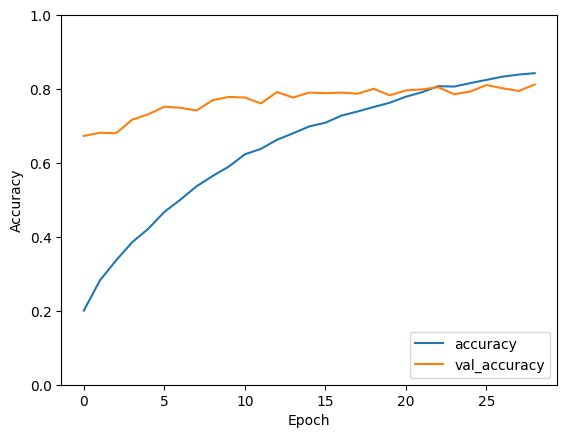

In [ ]:
accuracy_vs_epochs(history5_1)

In [ ]:
# model 6 model1 +  dropout + custom learning rate + LeakyReLU as activation
model6 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),

    LeakyReLU(alpha=0.1),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model6.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model6.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 12, 12, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       737,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,023,134 (3.90 MB)

 Trainable params: 1,023,134 (3.90 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history6 = training(model6, 'model6', train_ds, validation_ds, 'original')

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1324s 15s/step - accuracy: 0.0183 - loss: 4.1244 - val_accuracy: 0.0323 - val_loss: 4.1053
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - accuracy: 0.0495 - loss: 4.0170 - val_accuracy: 0.0924 - val_loss: 3.7576
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 257ms/step - accuracy: 0.1085 - loss: 3.6441 - val_accuracy: 0.2082 - val_loss: 3.3104
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.1701 - loss: 3.3104 - val_accuracy: 0.3065 - val_loss: 2.9092
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step - accuracy: 0.2416 - loss: 2.9791 - val_accuracy: 0.3651 - val_loss: 2.6447
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 257ms/step - accuracy: 0.2819 - loss: 2.7432 - val_accuracy: 0.3974 - val_loss: 2.4106
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step - accuracy: 0.3361 - loss: 2.5082 - val_accuracy: 0.4516 - val_loss: 2.1897
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.3886 - loss: 2.3079 - 

✅ Restored model6 from checkpoint
✅ Restored model6 original history (32 epochs)


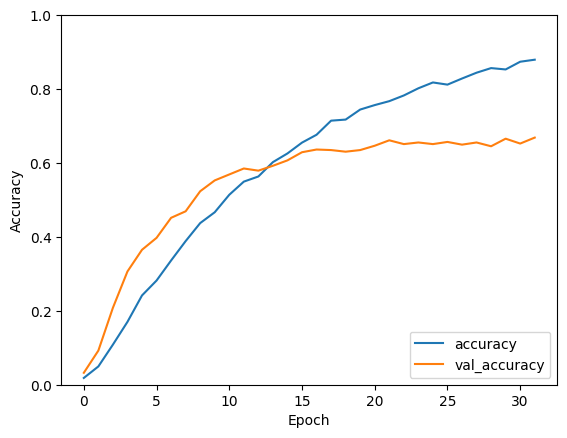

In [ ]:
model6 = restore_model("model6")
history6 = restore_history('model6', 'original')
accuracy_vs_epochs(history6)

In [ ]:
history6_1 = training(model6, 'model6', aug_ds, validation_ds, 'augmented')

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 4519s 21s/step - accuracy: 0.2318 - loss: 3.2408 - val_accuracy: 0.6686 - val_loss: 1.3629
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 112s 522ms/step - accuracy: 0.3255 - loss: 2.5631 - val_accuracy: 0.6789 - val_loss: 1.1734
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 105s 489ms/step - accuracy: 0.3976 - loss: 2.2178 - val_accuracy: 0.7141 - val_loss: 1.0479
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 105s 491ms/step - accuracy: 0.4499 - loss: 1.9618 - val_accuracy: 0.7346 - val_loss: 0.9664
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 141s 483ms/step - accuracy: 0.5029 - loss: 1.7434 - val_accuracy: 0.7287 - val_loss: 0.9361
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 484ms/step - accuracy: 0.5502 - loss: 1.5647 - val_accuracy: 0.7537 - val_loss: 0.8624
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 104s 485ms/step - accuracy: 0.5880 - loss: 1.4038 - val_accuracy: 0.7434 - val_loss: 0.8681
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 143s 490ms/step - accuracy: 0

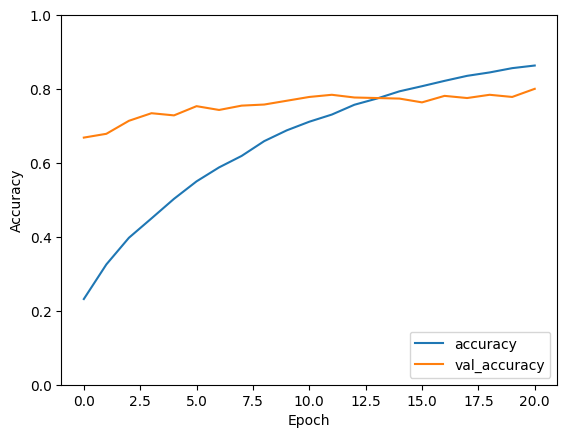

In [ ]:
accuracy_vs_epochs(history6_1)

## Models 3–6

Continuing from the checkpoint-restoration logic established with Models 1–2, here's the same analysis applied to Models 3–6, which add BatchNormalization, Dropout, a lower learning rate, and (for 4–6) LeakyReLU as variations on the base architecture.

### Model 3 (BatchNorm + Dropout + lower LR)

On the original dataset, Model 3's lowest val_loss (1.1632) occurred at epoch 38, corresponding to a validation accuracy of **66.57%**. Continuing on the augmented dataset, the lowest val_loss (0.6414) occurred much earlier — epoch 16 — corresponding to **81.23%** validation accuracy, the best result so far.

Training accuracy on the augmented run was still climbing (84.88% by epoch 26) while val_loss had already started drifting back up from its epoch-16 low (0.66 → 0.72 by the last logged epoch), the same early-peak-then-drift pattern seen in Models 1–2.

### Model 4 (+ LeakyReLU)

On the original dataset, Model 4's lowest val_loss (1.2029) occurred at epoch 48, corresponding to **68.04%** validation accuracy — a modest improvement over Model 3's original-data result. On the augmented dataset, the lowest val_loss (0.8319) occurred at epoch 10, corresponding to **75.95%** validation accuracy.

Notably, Model 4's augmented run degrades much faster after its best point than Model 3's did: by epoch 20 training accuracy has jumped to 77.65% while val_loss has climbed back to 1.25 — nearly double its best value in just 10 epochs. This is a sharper overfitting curve than Model 3 showed.

### Model 5 (LeakyReLU, no BatchNorm)

On the original dataset, Model 5's lowest val_loss (1.4287) occurred at epoch 32, corresponding to **66.28%** validation accuracy — noticeably worse than Model 3 or 4 on original data. On the augmented dataset, the lowest val_loss (0.6849) occurred at epoch 19, corresponding to **80.06%** validation accuracy, close to Model 3's augmented result.

Removing BatchNormalization didn't collapse performance the way a dying-ReLU scenario might have — LeakyReLU alone seems to keep gradients alive — but it also didn't improve on Model 3.

### Model 6 (LeakyReLU + larger dense layer, no BatchNorm)

On the original dataset, Model 6's lowest val_loss (1.3743) occurred at epoch 22, corresponding to **66.13%** validation accuracy. On the augmented dataset, the lowest val_loss (0.7661) occurred at epoch 11, corresponding to **77.86%** validation accuracy — worse than Model 3 or 5's augmented results, suggesting the wider dense layer (128 vs 64 units) added capacity without adding generalization.

### Comparison (restored checkpoint — lowest val_loss)

| Model | Original Data (val acc @ best val_loss) | Augmented Data (val acc @ best val_loss) | Best val_loss (augmented) |
|-------|---------------:|---------------:|---------------:|
| Model 3 | 66.57% (epoch 38) | **81.23%** (epoch 16) | **0.6414** |
| Model 4 | **68.04%** (epoch 48) | 75.95% (epoch 10) | 0.8319 |
| Model 5 | 66.28% (epoch 32) | 80.06% (epoch 19) | 0.6849 |
| Model 6 | 66.13% (epoch 22) | 77.86% (epoch 11) | 0.7661 |

Model 3 is the strongest of this batch on augmented data, both in accuracy and loss, and it's also the only one of the four whose best checkpoint doesn't collapse quickly afterward. Model 4 has the best *original*-data result but the worst augmented-data result, and its augmented val_loss roughly doubles within 10 epochs of its best point — the steepest overfitting curve seen yet. Models 5 and 6 (BatchNorm removed) land in between, showing that LeakyReLU without BatchNorm avoids catastrophic failure but doesn't beat the BatchNorm + Dropout + low-LR combination in Model 3.

Taken together with Models 1–2, the ranking on augmented val_loss is: **Model 3 (0.6414) > Model 2 (0.6099 — still the overall best) > Model 5 (0.6849) > Model 1 (0.6812) > Model 6 (0.7661) > Model 4 (0.8319)**. So none of the architectural changes in 3–6 actually beat Model 2 yet — they mostly moved the overfitting point around rather than closing the train/val gap.

## Where to go from here

A few honest observations from this round: the architecture tweaks (BatchNorm, Dropout, LeakyReLU, wider dense layer) shifted *when* overfitting kicks in but didn't meaningfully raise the accuracy ceiling — Model 2's simple setup is still competitive with or better than the more complex Models 3–6. That's a useful signal in itself: it points toward the data, not the architecture, being the current bottleneck for at least some of these models.

Planned next steps:

- **Separate "needs more capacity/regularization" models from "needs more data" models.** For models whose train/val gap opens up early and stays wide even after augmentation (Model 4 is the clearest case here), more augmented data is unlikely to be the fix by itself — architecture or regularization changes matter more there. For models where the gap narrows nicely on the augmented set but the model just hasn't seen enough variation yet (Model 3, and Model 2 previously), throwing more augmented data at them is the more promising lever.
- **Try swapping the dense/softmax head for a Random Forest on top of CNN features** (CNN as a fixed or fine-tuned feature extractor, flattened features fed into a Random Forest classifier instead of the Dense+Dropout+Softmax stack). This tests whether the overfitting is coming from the fully-connected classifier head specifically, versus the conv feature extractor.
- **If that doesn't move the needle, generate a larger/more varied augmented dataset** (beyond the current ~13,000 images — more aggressive or more diverse augmentation) and retrain.
- **Pick the best-performing model from these experiments** and focus further overfitting-reduction work specifically on that one, rather than continuing to spread experiments evenly across all six.